# UMAP + KMeans Chemical Clustering

This notebook shows a compact workflow for clustering molecules with chemically meaningful fingerprints, a UMAP embedding from mlchem, and KMeans from scikit-learn.

Workflow:
1. Load molecules.
2. Calculate fingerprints.
3. Search a small UMAP/KMeans grid.
4. Choose the best configuration.
5. Fit the final model and inspect each cluster.

In [85]:
import itertools
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

from mlchem.chem.calculator.descriptors import get_fingerprint_df
from mlchem.chem.manipulation import create_molecule
from mlchem.chem.visualise import drawing
from mlchem.ml.preprocessing.dimensional_reduction import Compressor

RANDOM_STATE = 1
FP_TYPE = 'm'
FP_RADIUS = 2
FP_N_BITS = 2048
KMEANS_N_INIT = 20
GRID_N_COMPONENTS = [2]
GRID_NEIGHBOUR_FRACTIONS = [0.01, 0.05, 0.1]
GRID_K = [5, 10, 20]

In [70]:
df_desc_rdkit = pd.read_csv('../data/data_rdkit.csv', index_col='SMILES')
data = pd.read_csv('../data/data.csv')

smiles = df_desc_rdkit.index.to_list()
fp_df = get_fingerprint_df(
    smiles,
    fp_type=FP_TYPE,
    radius=FP_RADIUS,
    nBits=FP_N_BITS,
)
fp_df.index = smiles

print(f'Loaded {len(smiles):,} molecules')
display(data.head())
display(df_desc_rdkit.head())
display(fp_df.head())

Loaded 595 molecules


,SMILES,CLASS
0,CO,0
1,C=NCCC(CCO)CCCCOC(=O)C=O,0
2,CCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,0
3,C#CCCCCOCCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,0
4,O=CC(=O)OCCCCC(CCO)CCN=CCC#CN=C=CCCOCCCCC1=CCC...,0


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
SMILES,,,,,,,,,,,,,,,,,,,,,
CO,7.000000,7.000000,1.000000,1.000000,0.385284,3.000000,32.042,28.010,32.026215,14,...,0,0,0,0,0,0,0,0,0,0
C=NCCC(CCO)CCCCOC(=O)C=O,10.509995,10.509995,0.170950,-0.812254,0.192921,11.823529,243.303,222.135,243.147058,98,...,0,0,0,0,0,0,0,0,1,0
CCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,10.666806,10.666806,0.156018,-0.822758,0.138151,11.120000,348.443,320.219,348.204907,138,...,0,0,0,0,0,0,0,0,1,0
C#CCCCCOCCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,10.726874,10.726874,0.142995,-0.829415,0.082425,11.000000,444.572,408.284,444.262422,176,...,0,0,0,1,0,0,0,0,3,0
O=CC(=O)OCCCCC(CCO)CCN=CCC#CN=C=CCCOCCCCC1=CCCC=C1,10.757642,10.757642,0.147038,-0.825632,0.065004,13.305556,498.664,456.328,498.309372,198,...,0,0,0,0,0,0,0,0,2,0


,m1,m2,m3,m4,m5,m6,m7,m8,m9,m10,...,m2039,m2040,m2041,m2042,m2043,m2044,m2045,m2046,m2047,m2048
CO,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C=NCCC(CCO)CCCCOC(=O)C=O,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C#CCCCCOCCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
O=CC(=O)OCCCCC(CCO)CCN=CCC#CN=C=CCCOCCCCC1=CCCC=C1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Grid search

Each UMAP configuration is fit once, cached, and then reused across all KMeans cluster counts.

In [75]:
def fit_umap_embedding(
    fp_frame: pd.DataFrame,
    n_components: int,
    neighbour_fraction: float,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    compressor = Compressor(fp_frame)
    compressor.compress_UMAP(
        n_components=n_components,
        neighbours_number_or_fraction=neighbour_fraction,
        random_state=random_state,
    )

    embedding = compressor.dataframe_compressed.copy()
    embedding.columns = [f'UMAP_{i + 1}' for i in range(embedding.shape[1])]
    return embedding


def score_kmeans_on_embedding(
    embedding: pd.DataFrame,
    n_components: int,
    neighbour_fraction: float,
    n_clusters: int,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, KMeans]:
    kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=KMEANS_N_INIT,
        random_state=random_state,
    )
    labels = kmeans.fit_predict(embedding)

    scores = {
        'n_components': n_components,
        'neighbour_fraction': neighbour_fraction,
        'n_clusters': n_clusters,
        'inertia': float(kmeans.inertia_),
        'silhouette': float(silhouette_score(embedding.values, labels)),
    }

    return pd.DataFrame([scores]), kmeans


results = []
umap_cache = {}
kmeans_models = {}

for n_components, neighbour_fraction, n_clusters in itertools.product(
    GRID_N_COMPONENTS,
    GRID_NEIGHBOUR_FRACTIONS,
    GRID_K,
):
    print(f'Fitting n_components={n_components}, neighbour_fraction={neighbour_fraction}, k={n_clusters}')
    umap_key = (n_components, neighbour_fraction)

    if umap_key not in umap_cache:
        umap_cache[umap_key] = fit_umap_embedding(
            fp_frame=fp_df,
            n_components=n_components,
            neighbour_fraction=neighbour_fraction,
        )

    embedding = umap_cache[umap_key]
    score_df, kmeans = score_kmeans_on_embedding(
        embedding=embedding,
        n_components=n_components,
        neighbour_fraction=neighbour_fraction,
        n_clusters=n_clusters,
    )

    results.append(score_df)
    kmeans_models[(n_components, neighbour_fraction, n_clusters)] = kmeans


results_df = pd.concat(results)
results_df['√(silhouette/inertia)'] = np.sqrt(results_df['silhouette'] / results_df['inertia'])
results_df.sort_values('√(silhouette/inertia)', ascending=False, inplace=True)
results_df

Fitting n_components=2, neighbour_fraction=0.01, k=5
Fitting n_components=2, neighbour_fraction=0.01, k=10
Fitting n_components=2, neighbour_fraction=0.01, k=20
Fitting n_components=2, neighbour_fraction=0.05, k=5
Fitting n_components=2, neighbour_fraction=0.05, k=10
Fitting n_components=2, neighbour_fraction=0.05, k=20
Fitting n_components=2, neighbour_fraction=0.1, k=5
Fitting n_components=2, neighbour_fraction=0.1, k=10
Fitting n_components=2, neighbour_fraction=0.1, k=20


,n_components,neighbour_fraction,n_clusters,inertia,silhouette,√(silhouette/inertia)
0,2,0.10,20,76.442001,0.359081,0.068538
0,2,0.05,20,88.871475,0.385323,0.065846
0,2,0.01,20,162.819336,0.418115,0.050675
0,2,0.10,10,159.306351,0.370769,0.048243
0,2,0.05,10,195.377365,0.380189,0.044113
0,2,0.01,10,365.221283,0.447511,0.035004
0,2,0.10,5,338.892975,0.372225,0.033141
0,2,0.05,5,405.539337,0.384252,0.030782
0,2,0.01,5,824.352051,0.442176,0.023160


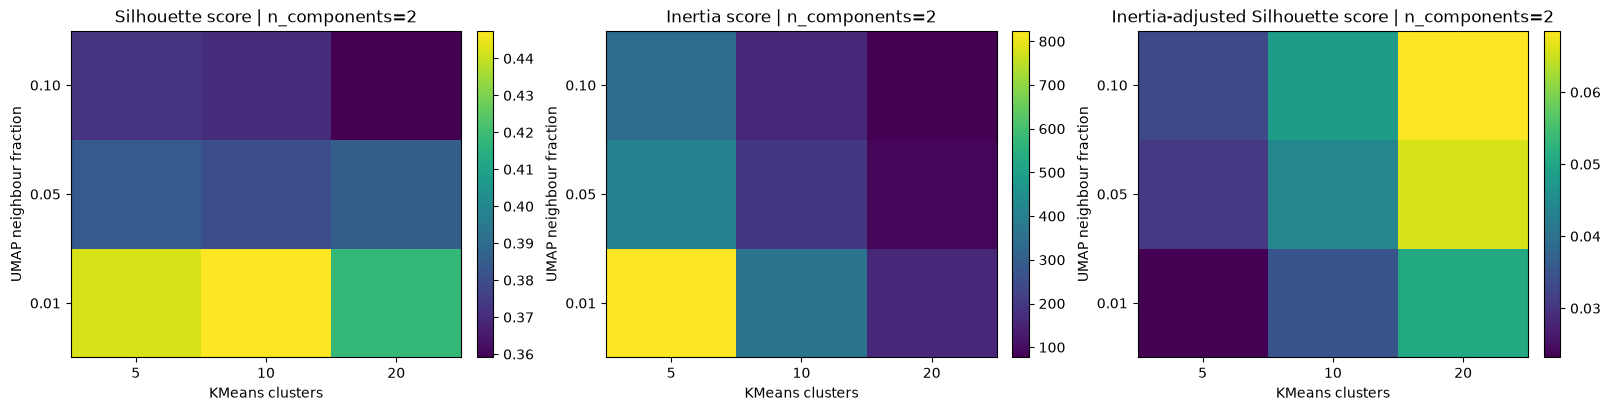

In [76]:
fig, axes = plt.subplots(len(GRID_N_COMPONENTS), 3, figsize=(16, 4 * len(GRID_N_COMPONENTS)), constrained_layout=True)
if len(GRID_N_COMPONENTS) == 1:
    axes = np.array([axes])

metric_names = ['silhouette', 'inertia', '√(silhouette/inertia)']
metric_titles = {
    'silhouette': 'Silhouette score',
    'inertia': 'Inertia score',
    '√(silhouette/inertia)': 'Inertia-adjusted Silhouette score',
}

for row_index, n_components in enumerate(GRID_N_COMPONENTS):
    subset = results_df[results_df['n_components'] == n_components]
    for col_index, metric in enumerate(metric_names):
        table = subset.pivot(index='neighbour_fraction', columns='n_clusters', values=metric)
        ax = axes[row_index, col_index]
        image = ax.imshow(table.values, aspect='auto', origin='lower', cmap='viridis')
        ax.set_title(f'{metric_titles[metric]} | n_components={n_components}')
        ax.set_xlabel('KMeans clusters')
        ax.set_ylabel('UMAP neighbour fraction')
        ax.set_xticks(range(len(table.columns)))
        ax.set_xticklabels(table.columns)
        ax.set_yticks(range(len(table.index)))
        ax.set_yticklabels([f'{value:.2f}' for value in table.index])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.show()

## Select the best configuration

Choose the configuration with the highest silhouette score, using Davies-Bouldin as the tie-breaker.

In [78]:


BEST_N_COMPONENTS = 2
BEST_NEIGHBOUR_FRACTION = 0.05
BEST_K = 20

print(
    f'Best configuration: n_components={BEST_N_COMPONENTS}, '
    f'neighbour_fraction={BEST_NEIGHBOUR_FRACTION}, k={BEST_K}'
)

Best configuration: n_components=2, neighbour_fraction=0.05, k=20


## Final model

Run the final UMAP + KMeans workflow once with the selected hyperparameters.

,SMILES,cluster,UMAP_1,UMAP_2,distance_to_centroid,CLASS
0,CO,3,18.030107,4.623362,0.354659,0
1,C=NCCC(CCO)CCCCOC(=O)C=O,7,17.263897,6.531419,0.562239,0
2,CCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,7,17.279251,6.665679,0.431734,0
3,C#CCCCCOCCC=C=NC#CCC=NCCC(CCO)CCCCOC(=O)C=O,7,17.150152,6.629778,0.526882,0
4,O=CC(=O)OCCCCC(CCO)CCN=CCC#CN=C=CCCOCCCCC1=CCC...,7,17.177183,6.557445,0.574071,0


Final inertia: 88.871
Observed clusters: 20


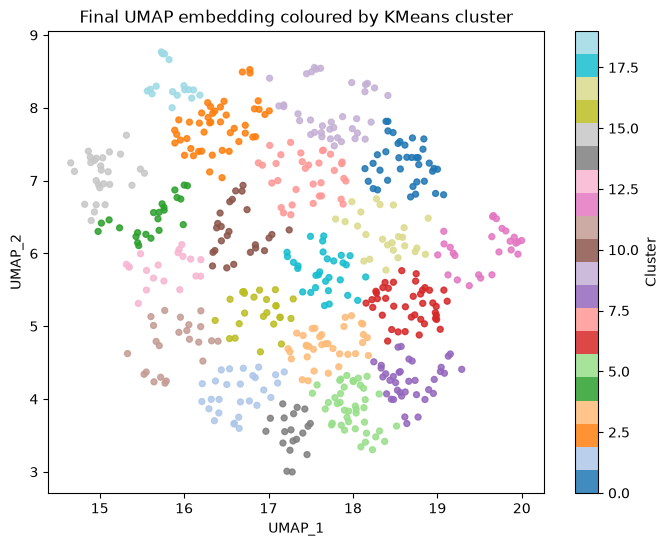

In [79]:
final_embedding = fit_umap_embedding(
    fp_frame=fp_df,
    n_components=BEST_N_COMPONENTS,
    neighbour_fraction=BEST_NEIGHBOUR_FRACTION,
)

final_kmeans = KMeans(
    n_clusters=BEST_K,
    n_init=KMEANS_N_INIT,
    random_state=RANDOM_STATE,
)
final_labels = final_kmeans.fit_predict(final_embedding)

clustered_df = pd.DataFrame({'SMILES': smiles, 'cluster': final_labels})
for column in final_embedding.columns:
    clustered_df[column] = final_embedding[column].values

clustered_df['distance_to_centroid'] = np.linalg.norm(
    final_embedding.values - final_kmeans.cluster_centers_[final_labels],
    axis=1,
)

if 'CLASS' in data.columns:
    clustered_df['CLASS'] = data['CLASS'].values

display(clustered_df.head())
print(f'Final inertia: {final_kmeans.inertia_:.3f}')
print(f'Observed clusters: {np.unique(final_labels).size}')

plt.figure(figsize=(8, 6))
plt.scatter(
    clustered_df['UMAP_1'],
    clustered_df['UMAP_2'],
    c=clustered_df['cluster'],
    s=18,
    cmap='tab20',
    alpha=0.85,
)
plt.xlabel('UMAP_1')
plt.ylabel('UMAP_2')
plt.title('Final UMAP embedding coloured by KMeans cluster')
plt.colorbar(label='Cluster')
plt.show()

## Inspect cluster composition

List the molecules in each cluster and display representative structures closest to the centroid in embedding space.

,n_molecules
cluster,
0,37
1,28
2,46
3,35
4,23
5,42
6,41
7,33
8,37


Cluster 0 | n=37


,SMILES,distance_to_centroid
378,CCCCCCCCCNC,0.084025
379,CC#CCCCCCCCNCCCCCCCCCCCCNC,0.095495
77,CCCCNC=CO,0.099568
325,CC=CNCCCCCCC,0.114428
568,CCCCCC,0.158675
512,CCCCCSCCCC,0.169521
513,CCCCCNO,0.178322
419,CCCCCCCCCCC,0.246778
23,CCCCCCC(O)CC,0.270655
449,CCCCCC1CC=CCC(C)NCC1,0.280315


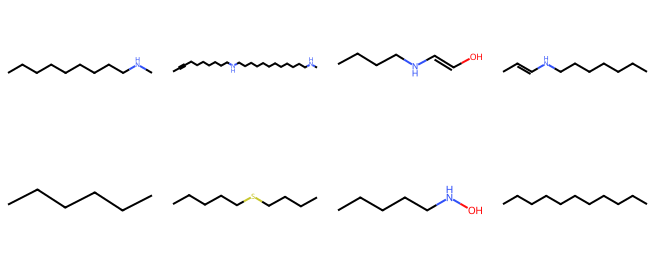

Cluster 1 | n=28


,SMILES,distance_to_centroid
390,NC=O,0.115526
540,O=C=CCCNCS,0.132412
444,C=COCN=CC,0.160978
537,CNC=O,0.189138
471,CC=COOC=O,0.245928
465,N=CCNCI,0.268295
228,C=CC#CCO,0.294347
266,C=CCBCC#CCO,0.298706
384,N=CO,0.300854
509,CC=N,0.323320


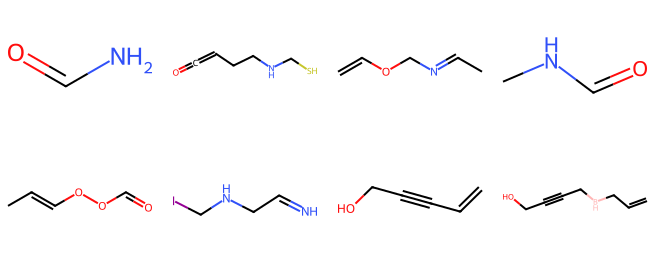

Cluster 2 | n=46


,SMILES,distance_to_centroid
168,CCCC=CCCCONCC=CCC(O)O,0.061851
163,CC=CC=C=CCC=CCCCO,0.105720
167,CCCCC=CCC(O)O,0.111751
593,CCCC=CCCC(C)CCCC=CCO,0.167675
249,CC=CCCCCCCCCO,0.169647
139,CCCCCCCC=CCCCC(O)CCCC,0.177372
295,CCC=CCCCO,0.189127
153,CC=CC=CCCCCCO,0.189180
162,CCCC=CCCCO,0.189264
271,CCCCC=CCCCCCCO,0.210934


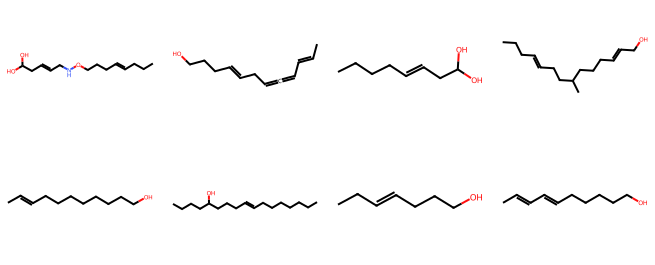

Cluster 3 | n=35


,SMILES,distance_to_centroid
43,CC1CCCCCCCCCCCC=CC=C(CCO)CNCCCCCCC1,0.026461
239,OCC1=CCCNCCCNCCCCCCCC=C=CC1,0.031018
42,OCCC1=CC=CCCCCCCCCCCCCNC1,0.064610
41,OCCC1=CC=CCCNC1,0.080302
11,OCC1=CCC1,0.148816
114,OCCC1=CCCN(O)CCCCC1,0.162796
238,OCC1=CCCCCC=C=CC1,0.170580
275,OCC1CCCCSC1,0.187696
233,CNC=CCCOOCCC#CO,0.216516
115,OCCC1CCCCCC2(O)CCC=C=C12,0.243398


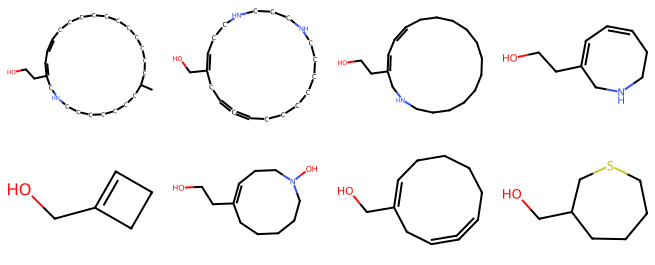

Cluster 4 | n=23


,SMILES,distance_to_centroid
170,C=CCCCC[N+]C(CCCCCCO[N+]=C)CCCONCC=CCC(O)O,0.076427
190,C=CCCCCO,0.078535
524,C=CCCOOCCCCCCCO,0.117473
187,C=CCCCCCCCCCO,0.184090
85,C=CCCCCC=C=CO,0.194646
169,C=CCCCC[N+]C(C)CCCONCC=CCC(O)O,0.207184
229,O=C=CCCCCO,0.230073
5,C=CCCCCC(CCC(CN)CCCCC(O)CNCCSCCC)NC,0.236132
304,C=CCCCCCCCCCC#SN=O,0.261801
323,C=CCC[N+]C#CC(N)CCCC,0.280385


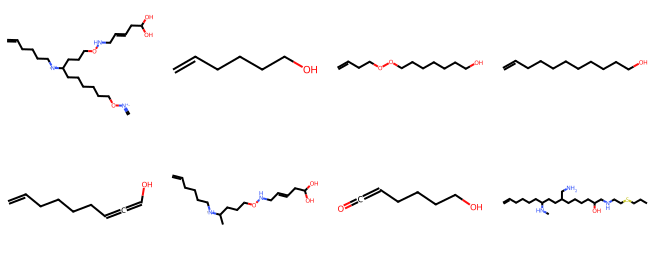

Cluster 5 | n=42


,SMILES,distance_to_centroid
399,C#[SH](C)C=CN,0.047389
574,C1#CCNCCNCCCCC1,0.047794
533,C1=NC1,0.058119
532,CC1=NOCC2CC2C=CCCC1,0.077490
364,C1#CCCCCC1,0.096713
560,NC1NCNCCNON=CO1,0.137949
382,C1COC1,0.139346
324,C1COCONCON1,0.166604
484,C#C,0.188640
482,CC(P=O)C1=CC1,0.190368


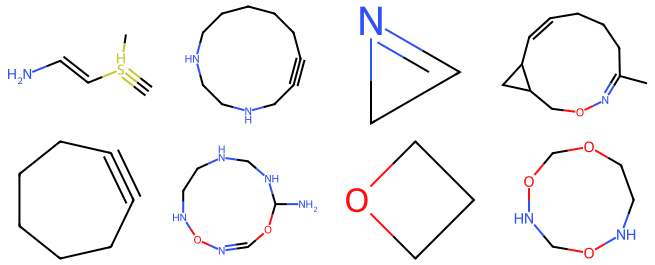

Cluster 6 | n=41


,SMILES,distance_to_centroid
360,CCC=C(Cl)CCCCS,0.045879
303,CCC,0.127333
442,C=NCC,0.161129
366,CCS,0.171322
105,CCOC(C)=BC=NC#CC1CCOCC1N1CC(C)CC(O)CCC[N+]C(C)C1,0.174502
374,CCNC,0.175424
563,CC=NCCC,0.205048
337,CCC1CN=NC1,0.250669
454,CCNOCC,0.259040
80,CC(C#CNI)CO,0.282038


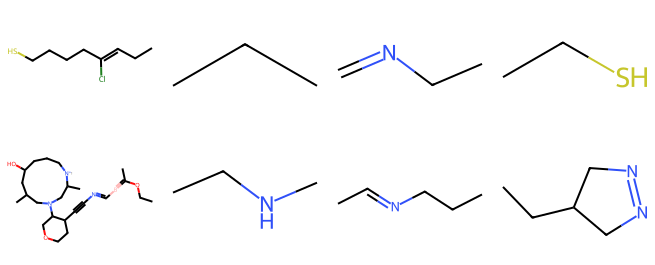

Cluster 7 | n=33


,SMILES,distance_to_centroid
31,CCOCCCO,0.109519
36,CC1CC=C(CCCCCCCCCCCCCCO)CCOC1,0.132617
161,CC=[N+](N)CCCO,0.154724
101,C=C(CC)CCCO,0.191469
242,NOCCCCO,0.207164
294,COCCCO,0.223001
59,N=CCNCCCCCO,0.231005
38,CC1=CCCCCC=C(CCCCCCCCCCCCCCO)CCOCC(C)C=NCCNCCCC1,0.310894
37,CC1C=NCCNCCCC=C(CCCCCCCCCCCCCCO)CCOC1,0.321775
55,NCCCCCCCCCO,0.326535


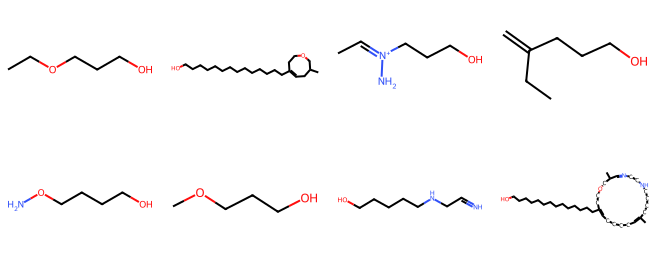

Cluster 8 | n=37


,SMILES,distance_to_centroid
470,C[N+]CC=CCl,0.015972
519,NCC#CO,0.064303
407,CC1C#CC1,0.163575
466,CC1CCCCCC(CNCI)NCCC1,0.166466
164,CO[N+]C=CO,0.167619
497,CF,0.169073
368,CP=CC1=C(C)OC1,0.197661
427,CI,0.200760
546,BC,0.202463
485,CCl,0.212550


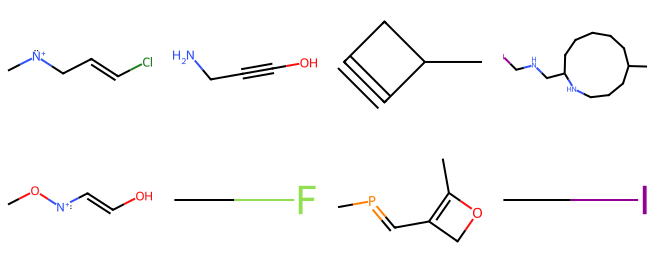

Cluster 9 | n=37


,SMILES,distance_to_centroid
297,CC1C=C1CCCCCO,0.144372
247,CCCCCCCCCOCC1=CCCSC(CCO)C1,0.157269
62,OCCCCCCCCCC1CCCONC1,0.219120
256,CCCCCCCCO,0.222460
246,CCCCCCCCCOC(CCC)CCO,0.242961
120,OCCCCCCCC1C=CCC=CCOCC1,0.265530
103,CC(C)[N+]CCCCO,0.310001
248,CCCCCCCCCOCC1=C(CNC=[N+])CCCSC(CCO)C1,0.322922
119,C=NCCCCCCCCCO,0.343661
67,CCCCCCSCNCCO,0.347554


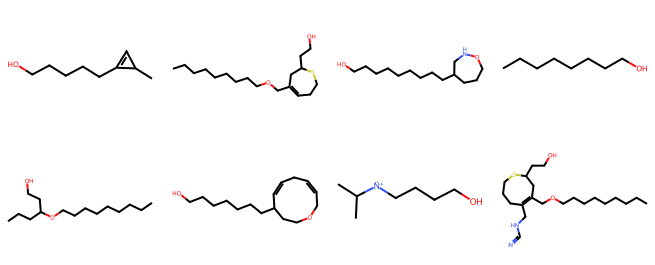

Cluster 10 | n=25


,SMILES,distance_to_centroid
186,CC#[PH]CCC#CCC=CCCO,0.102577
241,COC=CCCO,0.137401
185,CCC#CCC=CCCO,0.203804
244,CC=CCCO,0.234735
40,CCC=CCCO,0.252250
226,CN=CCC=CCCO,0.257328
178,B=C(NNCCCCC=C1CC1CCO)C1=C2CCCCCCOCCC1CCC2,0.283119
86,CC=CC(CCC)CCCC=C=CO,0.314254
194,CCC=CCC(C)CC=S(CCC=NC)C1=C(CCO)OCN1,0.316521
30,CCCC=CCCO,0.323030


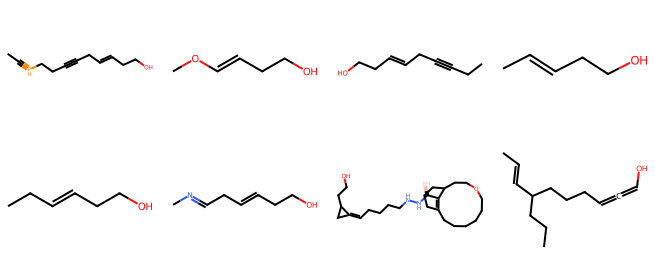

Cluster 11 | n=23


,SMILES,distance_to_centroid
576,CCC=NCC=O,0.176610
359,CC=C=NCC=CCC,0.180101
475,CC=C=CCC=CCC,0.196407
405,CCC=O,0.217998
573,CC=NC=CCC,0.246621
316,CC=C=CCC,0.293194
381,CC=CC1C#CCCC=[SH]CCOC1CC=CCC,0.325588
518,CCC=CC=O,0.360646
402,CCC=CCB=CC1=CNO1,0.385793
335,CC=CCC,0.400680


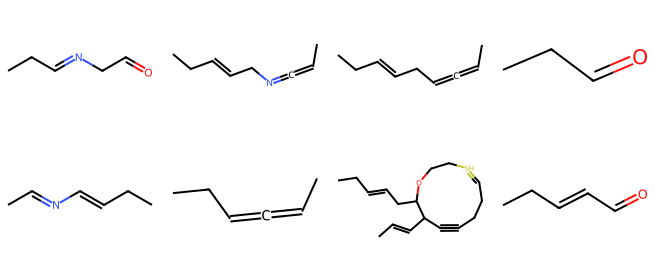

Cluster 12 | n=26


,SMILES,distance_to_centroid
353,C#CCCC,0.176845
18,C#CCCOCCCC(O)CC,0.183309
373,C#CCCCCC(Cl)CCOC#CNC#CO,0.315216
305,C#CCCCC,0.318614
410,C#CCCC(C)NCCCCC,0.345011
19,C#CCCOCCCC(C)(O)CCCCCCCC,0.348315
452,CCC#CCCC,0.364670
388,C#CCNCC,0.368244
534,C#CCCC=NC=C=[N+]CC,0.371336
260,CCCC#CO,0.377428


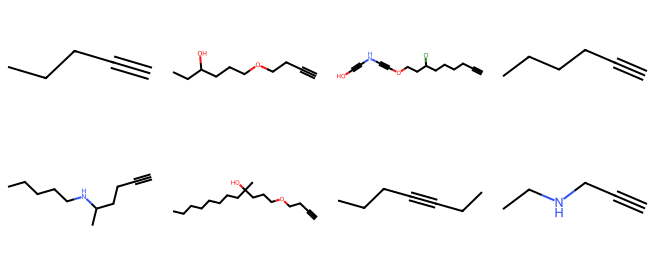

Cluster 13 | n=19


,SMILES,distance_to_centroid
387,C=CCCNON,0.087819
502,C=CCN=CCCNC=NC=C=NCCCl,0.170547
396,C=CCCC1=CN1CC,0.182577
377,C=CCCC,0.211804
267,O=CCCO,0.272625
179,C=CNCCCCCC=CCN=CCC=C=CCNNCO,0.278030
39,C=CCCO,0.315356
285,C=CNCC=CCCO,0.338600
536,C=CNCCC=NC=O,0.342599
562,C=CCCCCC=CCCC=NCC=C,0.347813


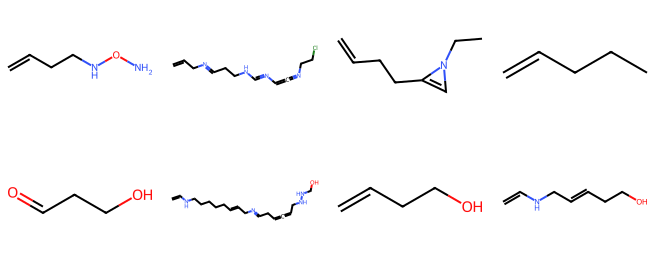

Cluster 14 | n=19


,SMILES,distance_to_centroid
343,C=C=O,0.037029
469,C=CCCS#CC1COCCCN1,0.084391
311,C=C=CO[N+],0.108870
570,C=C=C,0.117446
400,C=N,0.130248
317,C=C=CC,0.179079
342,C=CC=C=NCCCCS[N+]C(C)C,0.210858
430,C=CC[SH]=O,0.219090
553,C=C=[N+]=CC,0.245060
393,C=C(O)NSC1=CC=C1,0.251484


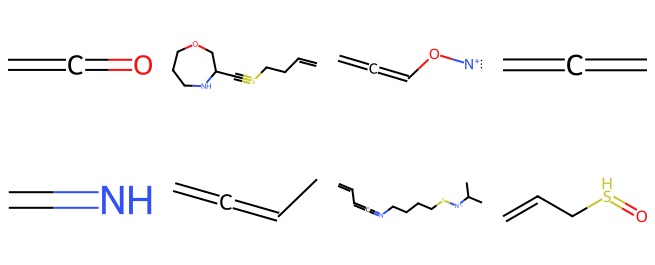

Cluster 15 | n=27


,SMILES,distance_to_centroid
421,CNCNCCCCC=O,0.069085
310,CCCCCC=O,0.079747
538,CCCCC(CCCC=NC)NC=O,0.108682
499,O=CCCCS1#CCCCCCC=C=CCCCC=1,0.120621
506,O=CCCCCC1CCCCC=[N+]CC1,0.127088
550,CSCCC#CCCCCCCC=O,0.140126
520,NCNC=CC=NCCCC=O,0.154391
592,CCCCC=O,0.178023
549,CCCCCCC=O,0.221217
355,O=CCCCCCCCCCCCCCCC1C=C1,0.222788


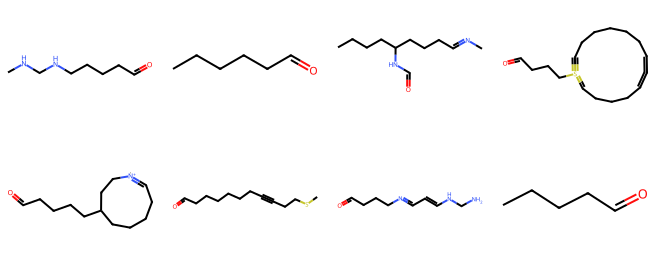

Cluster 16 | n=24


,SMILES,distance_to_centroid
251,C=CC=CCC=C=CCO,0.073393
280,C=C(C)COC=C=C=NCCO,0.089688
313,OC=CCCCl,0.173753
157,OCC#CCNCCC=CN1CC=CC1CC=C[N+]1=CS1,0.198304
156,OCC#CCNCCC=CN1CC=CC1,0.217653
279,OC=C=C=NCCO,0.218872
64,N#COCO[SH]=CCCO,0.219747
222,OCC=COP1C=NCC=NNCOCCCC1,0.233997
223,OCC=COP1CC=CCCN(CCI)NCC=NNCOCCCC1,0.253561
221,OCC=COP1CC1,0.257540


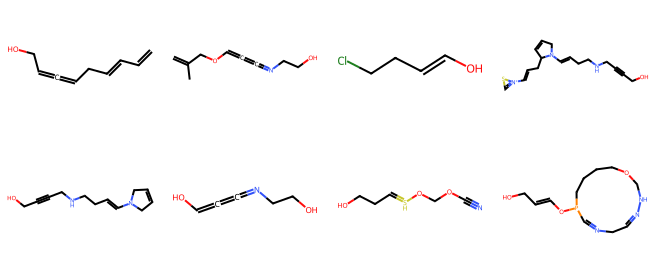

Cluster 17 | n=25


,SMILES,distance_to_centroid
82,CC=[N+]CCC=CCC#CC(O)CC(C)C#CNI,0.070352
227,CCC(C)CCO,0.136133
158,CCCC(C)C=NNCO,0.142156
122,CCCCO[SH]=[SH]NCCONCC(C)O,0.157400
75,CCCC(C)O,0.206903
10,CCCC(CC)CO,0.231529
121,CCCONCC(C)O,0.232165
76,CCCCC1=C(CCC(C)O)CCC1,0.241495
127,CCCC(C)C(C)O,0.274854
24,CCC(C)O,0.349694


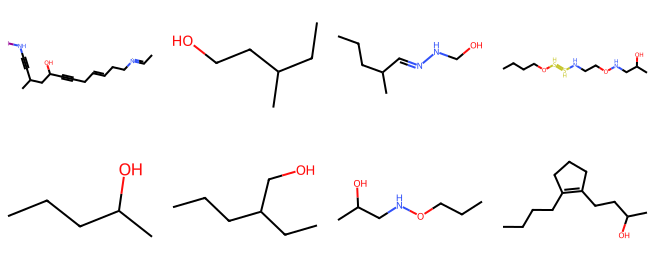

Cluster 18 | n=30


,SMILES,distance_to_centroid
130,CCC=PSCCO,0.049884
195,CC1=C(C=CNCO)C1,0.081194
191,CCC1=NCOC1CCO,0.105733
192,CC#CC1=C(CCO)OCN1,0.110606
79,CC1(CCO)CCO1,0.140369
166,C=CC=C(CCO)OCC,0.174169
45,CCNCO,0.182605
111,CCO,0.227807
96,CCNC=NC=CCO,0.247092
505,CC=CNCCNCCOCO,0.254079


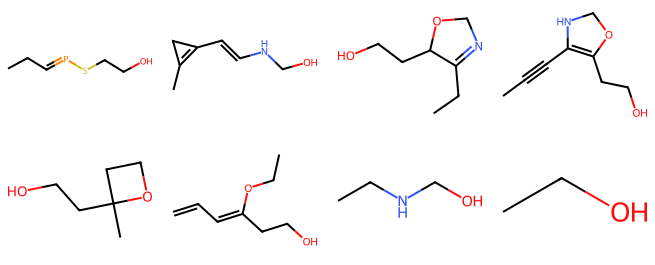

Cluster 19 | n=18


,SMILES,distance_to_centroid
293,CC(N)CNCNCCCCCCCCC=CCCCNCO,0.133923
159,OCCC=CCCCCCCNCCCCCF,0.154353
27,O=CCN[N+]=[N+]CCCCCC1CN1ONCCCCCCC=CCCO,0.187695
51,C=[N+]C=CC=CCCCCCC(C)CCCCCCCNCCCCC=CO,0.192468
292,CCCCCCCCC=CCCCNCO,0.193909
28,C#CCCCOCCN[N+]=[N+]CCCCCC1CN1ONCCCCCCC=CCCO,0.226165
50,C=[N+]CC(C)CCCCCCCNCCCCC=CO,0.273630
29,OCCC=CCCCCCCNON1CC1CCCCC[N+]=[N+]NCCOCCCCC1=C=...,0.280669
49,C=[N+]CCNCCCCC=CO,0.283222
133,OCCCC=CCCCCCNN1N=COOOCC2CCC21,0.308370


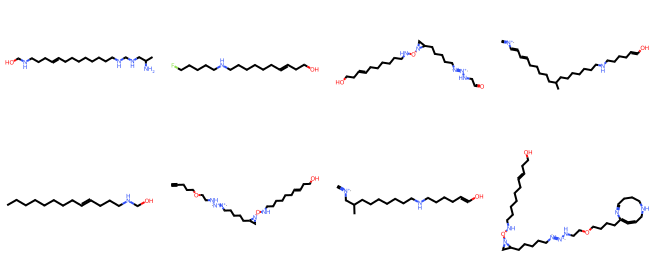

In [80]:
drawer = drawing.MolDrawer(size=(160, 130))
cluster_sizes = clustered_df['cluster'].value_counts().sort_index()
display(cluster_sizes.to_frame(name='n_molecules'))

for cluster_id, cluster_frame in clustered_df.sort_values('distance_to_centroid').groupby('cluster'):
    print(f'Cluster {cluster_id} | n={len(cluster_frame)}')
    display(cluster_frame[['SMILES', 'distance_to_centroid']].head(10))

    representative_smiles = cluster_frame.nsmallest(8, 'distance_to_centroid')['SMILES'].tolist()
    representative_molecules = [create_molecule(smiles_string) for smiles_string in representative_smiles]
    representative_images = [drawer.draw_mol(mol) for mol in representative_molecules]
    drawer.show_images_grid(images=representative_images, n_columns=4)

## Save cluster indices for modelling


In [86]:
best_kmeans = kmeans_models[(BEST_N_COMPONENTS, BEST_NEIGHBOUR_FRACTION, BEST_K)]
cluster_indices = best_kmeans.labels_
joblib.dump(cluster_indices, '../data/cluster_indices.pkl')
cluster_indices

array([ 3,  7,  7,  7,  7,  4, 15,  2,  9,  3, 17,  3,  2, 18, 17, 10, 16,
        9, 12, 12, 17, 17,  1,  0, 17,  2, 19, 19, 19, 19, 10,  7,  2,  9,
        9,  7,  7,  7,  7, 13, 10,  3,  3,  3,  2, 18, 16,  6, 17, 19, 19,
       19, 19, 18,  7,  7,  3,  5, 18,  7,  7,  9,  9, 16, 16, 16, 16,  9,
        7,  7, 16, 17,  7,  3, 18, 17, 17,  0,  3, 18,  6,  6, 17,  0,  0,
        4, 10,  5, 18,  5,  1, 17,  1, 18, 11, 10, 18,  0, 13,  1,  5,  7,
        7,  9,  8,  6,  6,  6,  9,  9, 18, 18, 18,  3,  3,  3,  3,  3,  0,
        9,  9, 17, 17,  5, 15, 15, 15, 17,  3, 10, 18,  2, 19, 19, 19, 19,
       19, 19,  2,  2,  9, 18,  9,  9,  9,  9,  6,  5, 16,  3,  3,  1,  1,
        2, 13, 18, 16, 16, 17, 19,  7,  7,  2,  2,  8, 13, 18,  2,  2,  4,
        4,  4,  4,  3,  3, 10, 10, 10, 10, 13,  7,  7,  7,  3,  4, 10, 10,
        4,  2,  2,  4, 18, 18, 10, 10, 18, 18, 16,  3, 10,  9,  2,  2,  2,
       17,  5,  5,  5,  5,  6, 18,  3,  2,  2,  2, 12, 12, 12,  7,  7,  7,
       16, 16, 16,  3,  1